# Convert Seurat object to AnnData object

##### Library

In [ ]:
import scanpy as sc
import anndata
from scipy import io
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np
import os
import pandas as pd
import anndata as ad
import loompy as lp

#### Load sparse matrix

In [7]:
X = io.mmread("Q:/Margaux_Labrosse/THESE/240524_scRNA_TAsc_MU_FSC/scAT-Fasc-Musc/02 - rds_reseq/Integrated_data/counts.mtx")

#### Create AnnData object

In [8]:
adata = anndata.AnnData(
    X=X.transpose().tocsr()
)

#### Load cell metadata

In [9]:
cell_meta = pd.read_csv("Q:/Margaux_Labrosse/THESE/240524_scRNA_TAsc_MU_FSC/scAT-Fasc-Musc/02 - rds_reseq/Integrated_data/metadata.csv")

C:\Users\margaux.labrosse\AppData\Local\Temp\ipykernel_9668\1955227369.py:1: DtypeWarning: Columns (58) have mixed types. Specify dtype option on import or set low_memory=False.
  cell_meta = pd.read_csv("Q:/Margaux_Labrosse/THESE/240524_scRNA_TAsc_MU_FSC/scAT-Fasc-Musc/02 - rds_reseq/Integrated_data/metadata.csv")


#### Load gene names

In [10]:
with open("Q:/Margaux_Labrosse/THESE/240524_scRNA_TAsc_MU_FSC/scAT-Fasc-Musc/02 - rds_reseq/Integrated_data/gene_names.csv", 'r') as f:
    gene_names = f.read().splitlines()

#### Set anndata observations and index

In [11]:
adata.obs = cell_meta
adata.obs.index = adata.obs['barcode']
adata.var.index = gene_names

#### Load dimensional reduction

In [12]:
pca = pd.read_csv("Q:/Margaux_Labrosse/THESE/240524_scRNA_TAsc_MU_FSC/scAT-Fasc-Musc/02 - rds_reseq/Integrated_data/pca.csv")
pca.index = adata.obs.index

#### Set PCA and UMAP

In [13]:
adata.obsm['X_pca'] = pca.to_numpy()
adata.obsm['X_umap'] = np.vstack((adata.obs['UMAP_1'].to_numpy(), adata.obs['UMAP_2'].to_numpy())).T

#### Plot a UMAP to test

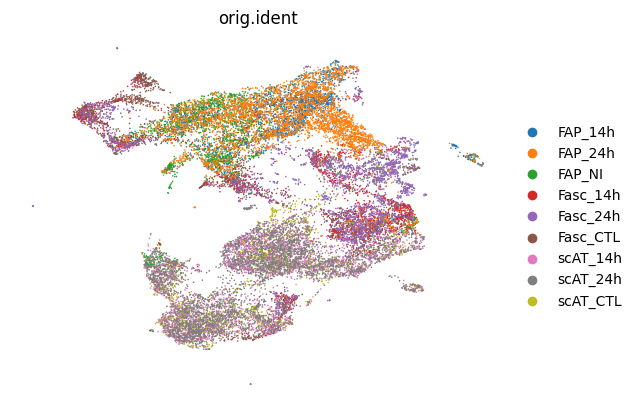

In [14]:
sc.pl.umap(adata, color=['orig.ident'], frameon=False)

### Save dataset as Anndata format - for later visualization

In [ ]:
adata.write('../data/ASC_FSC_FAP_SCT.h5ad')

### Generate a loom file - for SCENIC pipeline

In [ ]:
row_attrs = {
    "Gene": np.array(adata.var_names) ,
}
col_attrs = {
    "CellID": np.array(adata.obs_names) ,
    "nGene": np.array( np.sum(adata.X.transpose()>0 , axis=0)).flatten() ,
    "nUMI": np.array( np.sum(adata.X.transpose() , axis=0)).flatten() ,
}
lp.create( "../data/ASC_scenic_count.loom" , adata.X.transpose(), row_attrs, col_attrs)

#### Check the loom file

In [ ]:
ds = loompy.connect("../data/ASC_scenic_count.loom", mode="r")

In [ ]:
print("Layers:", ds.layers.keys())
print("Row attributes (genes):", ds.ra.keys())  # Gene metadata
print("Column attributes (cells):", ds.ca.keys())  # Cell metadata
ds.close()